In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as settings
import numpy as np
import h5py
import ast

from astropy.convolution import convolve, Box1DKernel, Gaussian1DKernel

from utility.plot_from_hdf5 import plot_from_hdf5
from utility.plot_spectrum import plot_spectrum
from pipeline.processing.remove_spikes import remove_spikes
from pipeline.processing.fit_continuum import _powerlaw
from pipeline.processing.fit_gaussians import _gaussian, _two_gaussian
from pipeline.processing.scale_civ_to_nv import _civ_template
from pipeline.processing.parameters import CIV_FIT_WINDOW, LYA_NV_FIT_WINDOW, NV_LYA_CONTINUUM_WINDOWS, CIV_CONTINUUM_WINDOWS, CIV_AIR, NV_AIR, LYA_AIR
from utility.my_colors import palette_dark


DETAILS_PATH = "data/result_details.csv"
RELEVANT_RESULTS_PATH = "data/relevant_results.csv"
SPECTRA_PATH = "data/spectra.h5"

In [18]:
results = pd.read_csv(RELEVANT_RESULTS_PATH,index_col=0,dtype={"targetid":"str"})
details = pd.read_csv(DETAILS_PATH,dtype={"targetid":"str"},index_col=1)

In [20]:
core_erq_idx = results[(results["rew_civ"]>100) & (results["z-w3"]>3.9) & (results["z"]>2) & (results["z"]<3.4) & (results["snr_w3"]>3)].index

In [116]:
def plot_cell(targetid,ax,yticks_right=0):
    targetid = str(targetid)

    with h5py.File(SPECTRA_PATH, "r") as f:
        data = f[f"{targetid}"][()]
        
    lam = data[0,:]
    flux = data[1,:]
    ivar = data[2,:]

    flux_clean, _ = remove_spikes(lam, flux, ivar=ivar)

    #-------------------------------------------------------------------------------------

    cont_params = ast.literal_eval(details.loc[targetid,"continuum_fit_lya_nv"])["fit_params"]
    cont_flux = _powerlaw(lam/1290,**cont_params)

    #-------------------------------------------------------------------------------------

    civ_params = ast.literal_eval(details.loc[targetid,"line_fit_civ"])
    civ_integration_window = ast.literal_eval(details.loc[targetid,"measurements_civ"])["integration_window"]

    if civ_params["accept_two"]:
        civ_profile = _two_gaussian(lam,civ_params["fit_params"]["amp_c"],civ_params["fit_params"]["cen_c"],civ_params["fit_params"]["sigma_c"],civ_params["fit_params"]["amp_w"],civ_params["fit_params"]["cen_w"],civ_params["fit_params"]["sigma_w"])
    else:
        civ_profile = _gaussian(lam, civ_params["fit_params"]["amplitude"],civ_params["fit_params"]["center"],civ_params["fit_params"]["sigma"])

    civ_cont_params = ast.literal_eval(details.loc[targetid,"continuum_fit_civ"])
    civ_cont_profile = civ_cont_params["fit_params"]["amplitude"] * ((lam / 1700.0) ** civ_cont_params["fit_params"]["alpha"])

    civ_profile += civ_cont_profile

    civ_mask = (lam > civ_integration_window[0]) & (lam < civ_integration_window[1])
    civ_lam = lam[civ_mask]
    civ_profile = civ_profile[civ_mask]

    #-------------------------------------------------------------------------------------

    nv_params = ast.literal_eval(details.loc[targetid,"line_fit_nv"])
    nv_integration_window = ast.literal_eval(details.loc[targetid,"measurements_nv"])["integration_window"]

    nv_profile = _civ_template(lam, nv_params["fit_params"]["scale"], nv_params["fit_params"]["shift"], civ_params["fit_params"], civ_params["accept_two"])+cont_flux

    nv_mask = (lam > nv_integration_window[0]) & (lam < nv_integration_window[1])
    nv_lam = lam[nv_mask]
    nv_profile = nv_profile[nv_mask]

    #-------------------------------------------------------------------------------------

    lya_params = ast.literal_eval(details.loc[targetid,"line_fit_lya"])
    lya_integration_window = ast.literal_eval(details.loc[targetid,"measurements_lya"])["integration_window"]

    if lya_params["accept_two"]:
        lya_profile = _two_gaussian(lam,lya_params["fit_params"]["amp_c"],lya_params["fit_params"]["cen_c"],lya_params["fit_params"]["sigma_c"],lya_params["fit_params"]["amp_w"],lya_params["fit_params"]["cen_w"],lya_params["fit_params"]["sigma_w"])+cont_flux
    else:
        lya_profile = _gaussian(lam, lya_params["fit_params"]["amplitude"],lya_params["fit_params"]["center"],lya_params["fit_params"]["sigma"])+cont_flux

    lya_mask = (lam > lya_integration_window[0]) & (lam < lya_integration_window[1])
    lya_lam = lam[lya_mask]
    lya_profile = lya_profile[lya_mask]

    #-------------------------------------------------------------------------------------

    plot_mask = (lam < 1680) & (lam > 1150)

    ax.plot(lam[plot_mask],convolve(flux_clean[plot_mask],Box1DKernel(5)),color="#222222",linewidth=0.5)

    ax.plot(lam[civ_mask],civ_profile,linewidth=1.5,label="CIV fit",color=palette_dark[1])
    ax.plot(lam[nv_mask],nv_profile,linewidth=1.5,label="NV fit",color=palette_dark[0])
    ax.plot(lam[lya_mask],lya_profile,linewidth=1.5,label=r"Ly$\alpha$ fit",color=palette_dark[2])

    ax.set_xlim(1150,1620)

    if yticks_right == 1:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

In [118]:
fig, axes = plt.subplots(7,2,figsize=(14,21),sharex=True,dpi=500)

for i, ax in enumerate(axes.flatten()):
    plot_cell(targetid=core_erq_idx[i],ax=ax,yticks_right=i%2)

# remove whitespace between plots 
fig.subplots_adjust(
    left=0.1, right=0.98, bottom=0.1, top=0.92,
    wspace=0, hspace=0                             
)

plt.show()

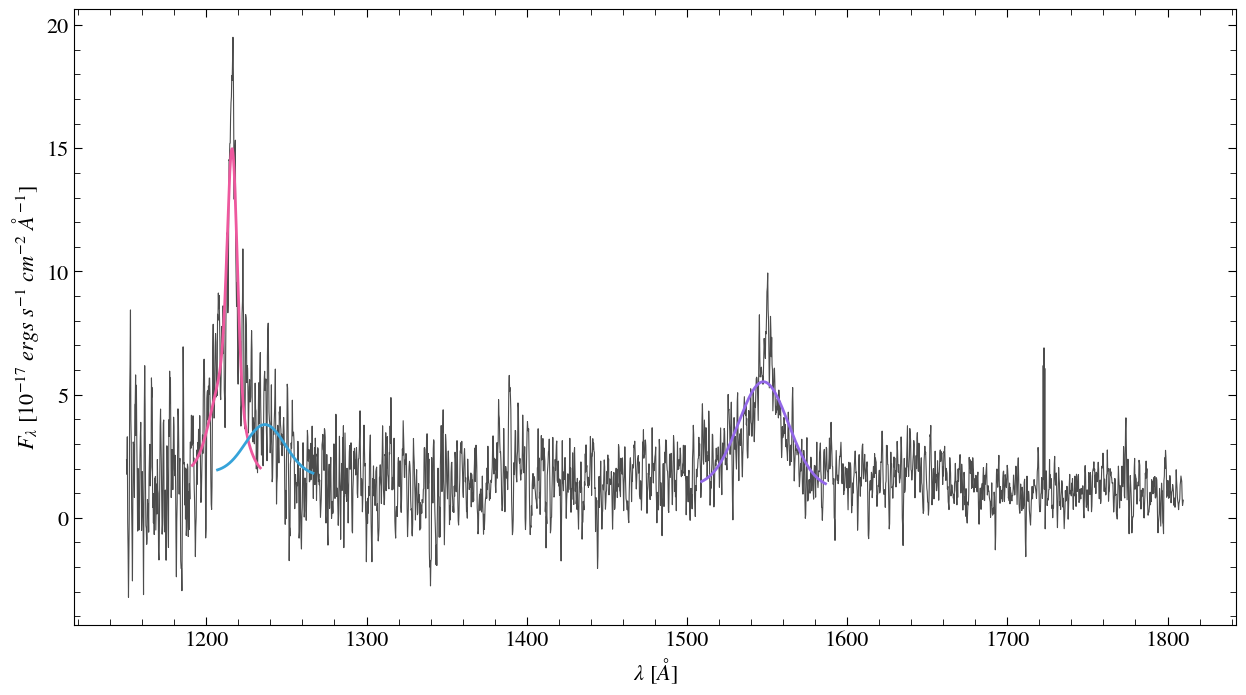

In [31]:
i = 1471

plot_from_hdf5(str(core_erq_idx[i]),df=details,LYA=True,CIV=True,NV=True)